# Porcentajes de cobertura por polígono

In [ ]:
import geopandas as gpd
import pandas as pd

# A) Carga de capas
gdf = gpd.read_file("D:\Semestre 2025-1\Analisis Geoespacial\SHP\Amenaza_con_Morfometria.shp")
cov = gpd.read_file("D:\Semestre 2025-1\Analisis Geoespacial\SHP\Coberturas_MedellinZonaUrbana.shp")

# B) Unificar CRS
cov = cov.to_crs(gdf.crs)

# C) Crear ID único de polígono
gdf = gdf.reset_index().rename(columns={'index':'poly_id'})

# D) Intersección polígono × cobertura
inter = gpd.overlay(
    gdf[['poly_id','geometry']], 
    cov[['tipo','geometry']], 
    how='intersection'
)

# E) Área de cada intersección
inter['area_int'] = inter.geometry.area

# F) Sumar área por (poly_id, clase de cobertura)
areas = (
    inter
    .groupby(['poly_id','tipo'])['area_int']
    .sum()
    .reset_index()
)

# G) Area total de cada polígono (para porcentaje)
gdf['area_poly'] = gdf.geometry.area

# H) Pivot a formato ancho y cálculo de porcentaje
pivot = (
    areas
    .pivot(index='poly_id', columns='tipo', values='area_int')
    .fillna(0)
)
# divide por área total y multiplica por 100
for cov_type in pivot.columns:
    gdf[f"pct_cov_{cov_type}"] = pivot[cov_type] / gdf['area_poly'] * 100

# Ahora gdf tiene columnas pct_cov_<tipo> con el % de cada cobertura
gdf.to_file("Amenaza_Enriquecida.shp")

# Modelo final

In [113]:
import geopandas as gpd
import numpy as np
import libpysal
import statsmodels.api as sm
from esda.moran import Moran
from sklearn.preprocessing import StandardScaler

# 1) Cargar polígonos y red hídrica
gdf     = gpd.read_file("Amenaza_Enriquecida.shp").to_crs(epsg=3857)
streams = gpd.read_file(r"D:\Semestre 2025-1\Analisis Geoespacial\SHP\Red_hidrica_Medellin_ZonaUrbana.shp").to_crs(gdf.crs)

# 2) Calcular longitud de cauce dentro de cada polígono
#    (y densidad de red: longitud/área)
gdf["stream_len"] = gdf.geometry.apply(
    lambda P: streams.intersection(P).length.sum()
)
gdf["stream_den"] = gdf["stream_len"] / gdf["area_poly"]

# 3) Preparar matriz de diseño X_base con estas dos nuevas variables
base = ["Elevacion_","Pendiente_","Aspecto_me","Curvatura_","TPI_mean","TRI_mean"]
cov  = ["pct_cov_Bo","pct_cov_Su","pct_cov_Te","pct_cov__1"]
red  = ["stream_len","stream_den"]
X_df = gdf[base + cov + red].fillna(0)
X_df = sm.add_constant(X_df)

# 4) Volver a calcular los 15 autovectores positivos (ESF) con la misma W de kNN5
coords = np.vstack([gdf.geometry.centroid.x, gdf.geometry.centroid.y]).T
knn    = libpysal.weights.KNN.from_array(coords, k=5)
knn.transform = "R"
W = knn.full()[0]
n = len(gdf)
M = np.eye(n) - np.ones((n,n))/n
C = M.dot(W).dot(M)
eigs, vecs = np.linalg.eigh(C)
mask = eigs>1e-6
idx  = eigs[mask].argsort()[::-1][:13]
EV15 = vecs[:,mask][:,idx]

# 5) Armar X final (base + red + ESF)
for i in range(13):
    X_df[f"EV_{i+1}"] = EV15[:,i]
X = X_df.values

if "count105" not in gdf.columns:
    events = (
        gpd.read_file(r"D:/Semestre 2025-1/Analisis Geoespacial/SHP/Inventario_inundaciones_lluvias_MedellinZonaUrbana.shp")
           .to_crs(gdf.crs)
    )
    joined = gpd.sjoin_nearest(
        events[["geometry"]],
        gdf[["poly_id", "geometry"]],
        how="left",
        max_distance=105,
        distance_col="dist"
    )
    counts = joined.groupby("poly_id").size()
    gdf["count105"] = gdf["poly_id"].map(counts).fillna(0).astype(int)

# 6) Definir y y offset (usando count105)
y      = gdf["count105"].values
gdf['area_poly'] = gdf.geometry.area
offset = np.log(gdf["area_poly"].values)

# 7) Ajustar NegBin + ESF + redes
model = sm.GLM(
    y,
    X,
    family=sm.families.NegativeBinomial(),
    offset=offset
).fit()

print(model.summary())
mi = Moran(model.resid_response, knn)
print(f"Moran’s I residuos: I={mi.I:.3f}, p={mi.p_sim:.3f}")


C:\Users\Usuario\.conda\envs\Geoespacial\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  502
Model:                            GLM   Df Residuals:                      476
Model Family:        NegativeBinomial   Df Model:                           25
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -369.34
Date:                Mon, 21 Jul 2025   Deviance:                       443.57
Time:                        23:13:29   Pearson chi2:                 2.23e+03
No. Iterations:                    32   Pseudo R-squ. (CS):             0.5111
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        475.1478    381.381      1.246      0.2

In [91]:
# 2) Calcula el área en m² y crea el offset
gdf['area_m2'] = gdf.geometry.area
offset = np.log(gdf['area_m2'].values)

# 3) Inspección rápida
print("Áreas en m² — min, q25, med, q75, max:")
print(gdf['area_m2'].describe()[['min','25%','50%','75%','max']])
print("\nOffset (log(m²)) — min, max:")
print(offset.min(), offset.max())

Áreas en m² — min, q25, med, q75, max:
min         5.881032
25%       984.244709
50%      3090.403148
75%      9449.604625
max    585912.388618
Name: area_m2, dtype: float64

Offset (log(m²)) — min, max:
1.7717322837188183 13.28092554990337


# Presentación

C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\geopandas\array.py:403: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


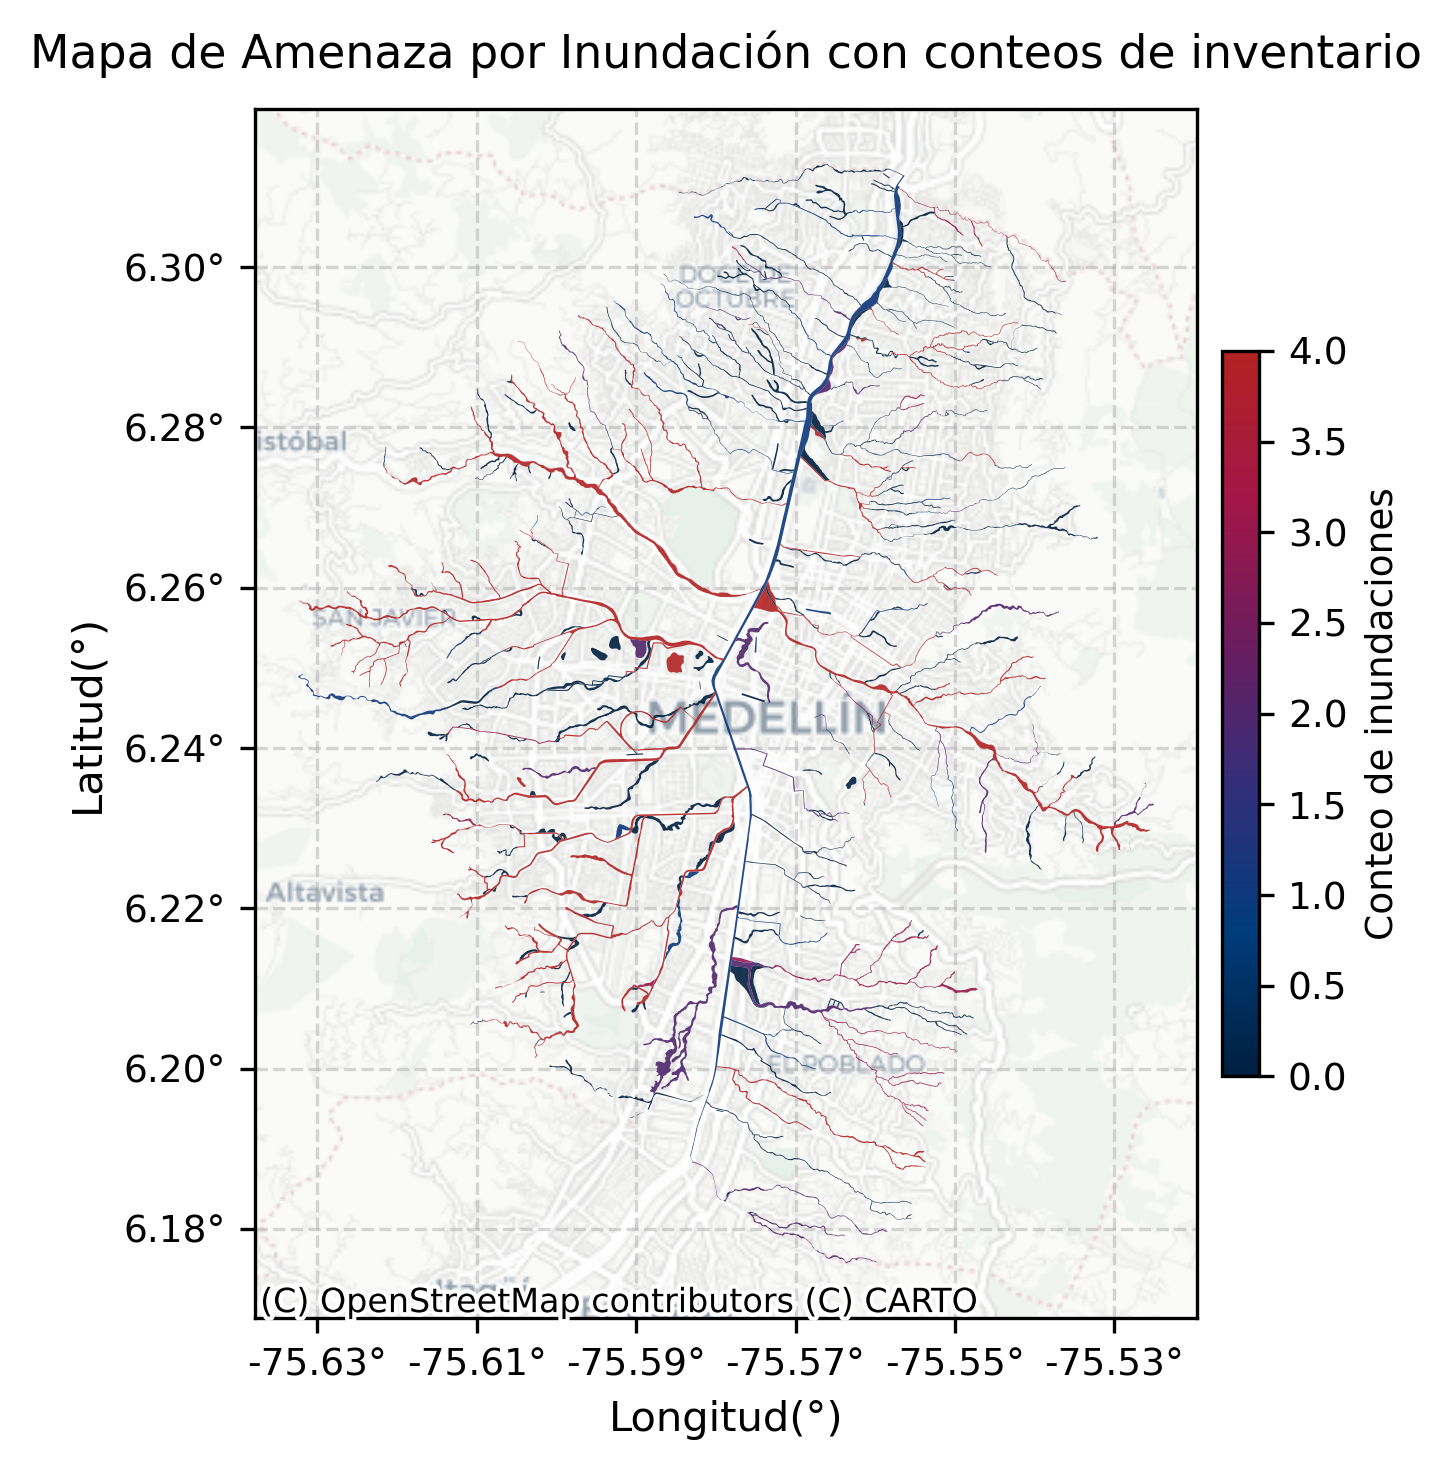

In [96]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import math
import numpy as np
import matplotlib.patheffects as pte
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.colors import LinearSegmentedColormap
# ——— Funciones de conversión lon/lat ⇄ WebMercator ———
R = 6378137.0
origin_shift = 2 * math.pi * R / 2.0

def lonlat_to_merc(lon, lat):
    x = lon * origin_shift / 180.0
    y = math.log(math.tan((90 + lat) * math.pi / 360.0)) * R
    return x, y

# ——— 1. Carga shapefile en WGS84 ———
gdf = (
    gpd.read_file("Amenaza_Enriquecida.shp")
       .to_crs(epsg=4326)
)

if "count105" not in gdf.columns:
    events = (
        gpd.read_file(r"D:/Semestre 2025-1/Analisis Geoespacial/SHP/Inventario_inundaciones_lluvias_MedellinZonaUrbana.shp")
           .to_crs(gdf.crs)
    )
    joined = gpd.sjoin_nearest(
        events[["geometry"]],
        gdf[["poly_id", "geometry"]],
        how="left",
        max_distance=105,
        distance_col="dist"
    )
    counts = joined.groupby("poly_id").size()
    gdf["count105"] = gdf["poly_id"].map(counts).fillna(0).astype(int)
# ——— 2. Calcula bbox en grados + pequeño buffer ———
min_lon, min_lat, max_lon, max_lat = gdf.total_bounds
buffer_deg = 0.01
min_lon, min_lat = min_lon - buffer_deg, min_lat - buffer_deg
max_lon, max_lat = max_lon + buffer_deg, max_lat + buffer_deg

# Convierte bbox a WebMercator (m)
min_x, min_y = lonlat_to_merc(min_lon, min_lat)
max_x, max_y = lonlat_to_merc(max_lon, max_lat)

# ——— 3. Proyecta tus polígonos a 3857 para que encajen con el tile ———
gdf_m = gdf.to_crs(epsg=3857)

# ——— 4. Descarga imagen de fondo ———
zoom_level = 12
img, img_ext = ctx.bounds2img(
    min_x, min_y, max_x, max_y,
    zoom=zoom_level,
    source=ctx.providers.OpenStreetMap.Mapnik
)

# ——— 5. Dibuja todo ———
fig, ax = plt.subplots(figsize=(5, 5),dpi=300)
# ——— 6. Ejes en grados + grilla ———
# Ticks cada 0.02°
lon_ticks = np.arange(math.floor(min_lon*100)/100, math.ceil(max_lon*100)/100, 0.02)
lat_ticks = np.arange(math.floor(min_lat*100)/100, math.ceil(max_lat*100)/100, 0.02)

x_ticks = [lonlat_to_merc(lon, 0)[0] for lon in lon_ticks]
y_ticks = [lonlat_to_merc(0, lat)[1] for lat in lat_ticks]

ax.set_xticks(x_ticks)
ax.set_xticklabels([f"{lon:.2f}°" for lon in lon_ticks], fontsize=10)
ax.set_yticks(y_ticks)
ax.set_yticklabels([f"{lat:.2f}°" for lat in lat_ticks], fontsize=10)
# Parámetros de la paleta
vmin, vmax = 0, gdf_m["count105"].max()
percentil95 = np.percentile(gdf_m["count105"], 95)
norm = Normalize(vmin=0, vmax=percentil95)
blue_red = [
    "#001f3f",  # azul noche
    "#003c7b",  # azul profundo
    "#332e7a",  # índigo oscuro
    "#6c1c5e",  # púrpura oscuro
    "#a41647",  # vino tinto
    "#b22222",  # rojo sangre
]

# 2) Crea un colormap continuo
cmap = LinearSegmentedColormap.from_list("blue_to_red", blue_red, N=256)
# 2) Polígonos “fill”
gdf_m.plot(
    column="count105",
    cmap=cmap,
    norm=norm,
    alpha=0.9,
    edgecolor="none",   # sin bordes aquí
    ax=ax,
    legend=False,       # manejamos colorbar por separado
    zorder=2
)


ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=12)
# 4) Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label("Conteo de inundaciones", fontsize=12)

# 5) Ejes en grados, grilla, títulos…

fontsize_axes = 10
fontsize_ticks = 9
fontsize_title = 11
fontsize_cbar = 9

ax.tick_params(axis='both', which='major', labelsize=fontsize_ticks)
cbar.ax.tick_params(labelsize=fontsize_ticks)  # tras crear el colorbar
cbar.set_label("Conteo de inundaciones", fontsize=fontsize_cbar)

ax.set_xlabel("Longitud(°)",fontsize=fontsize_axes)
ax.set_ylabel("Latitud(°)",fontsize=fontsize_axes)
ax.set_title("Mapa de Amenaza por Inundación con conteos de inventario", fontsize=fontsize_title,pad=10)
ax.grid(True, linestyle="--", alpha=0.5, zorder=1)

plt.tight_layout()
plt.show()

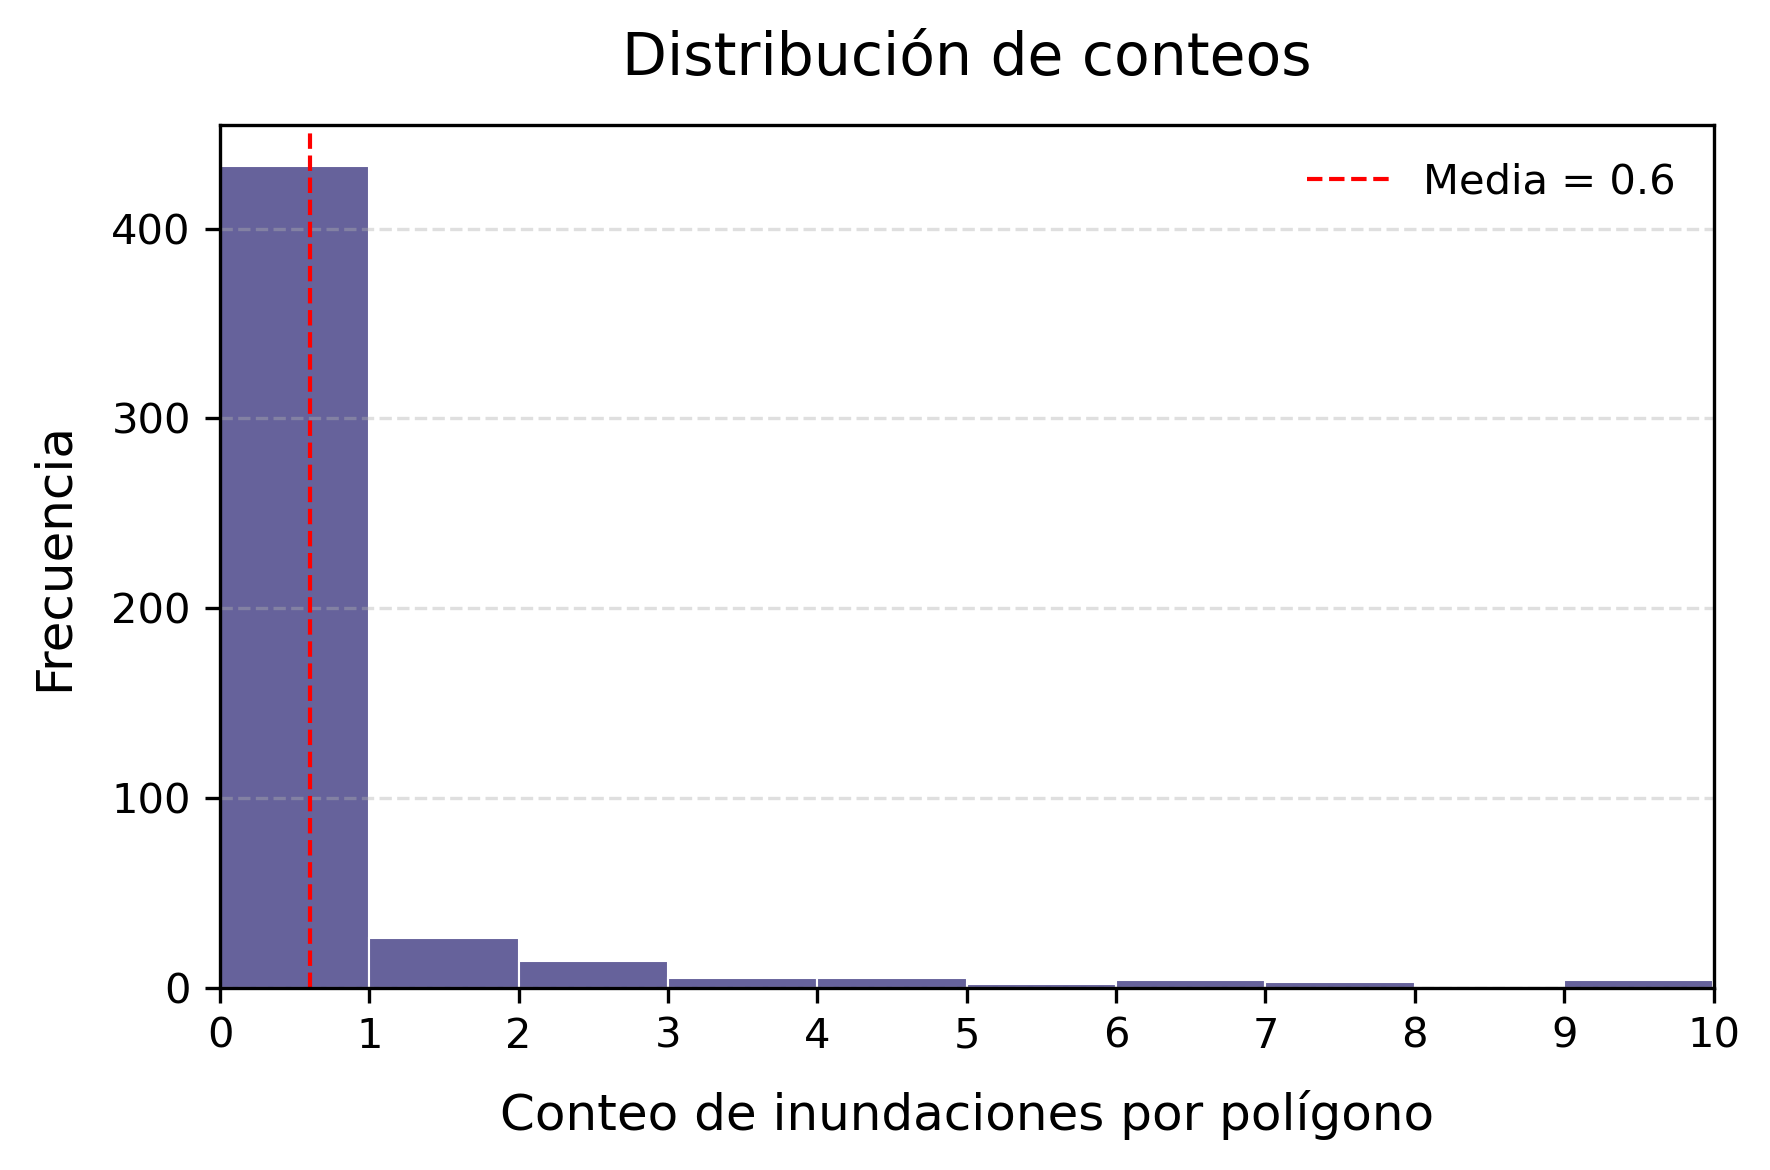

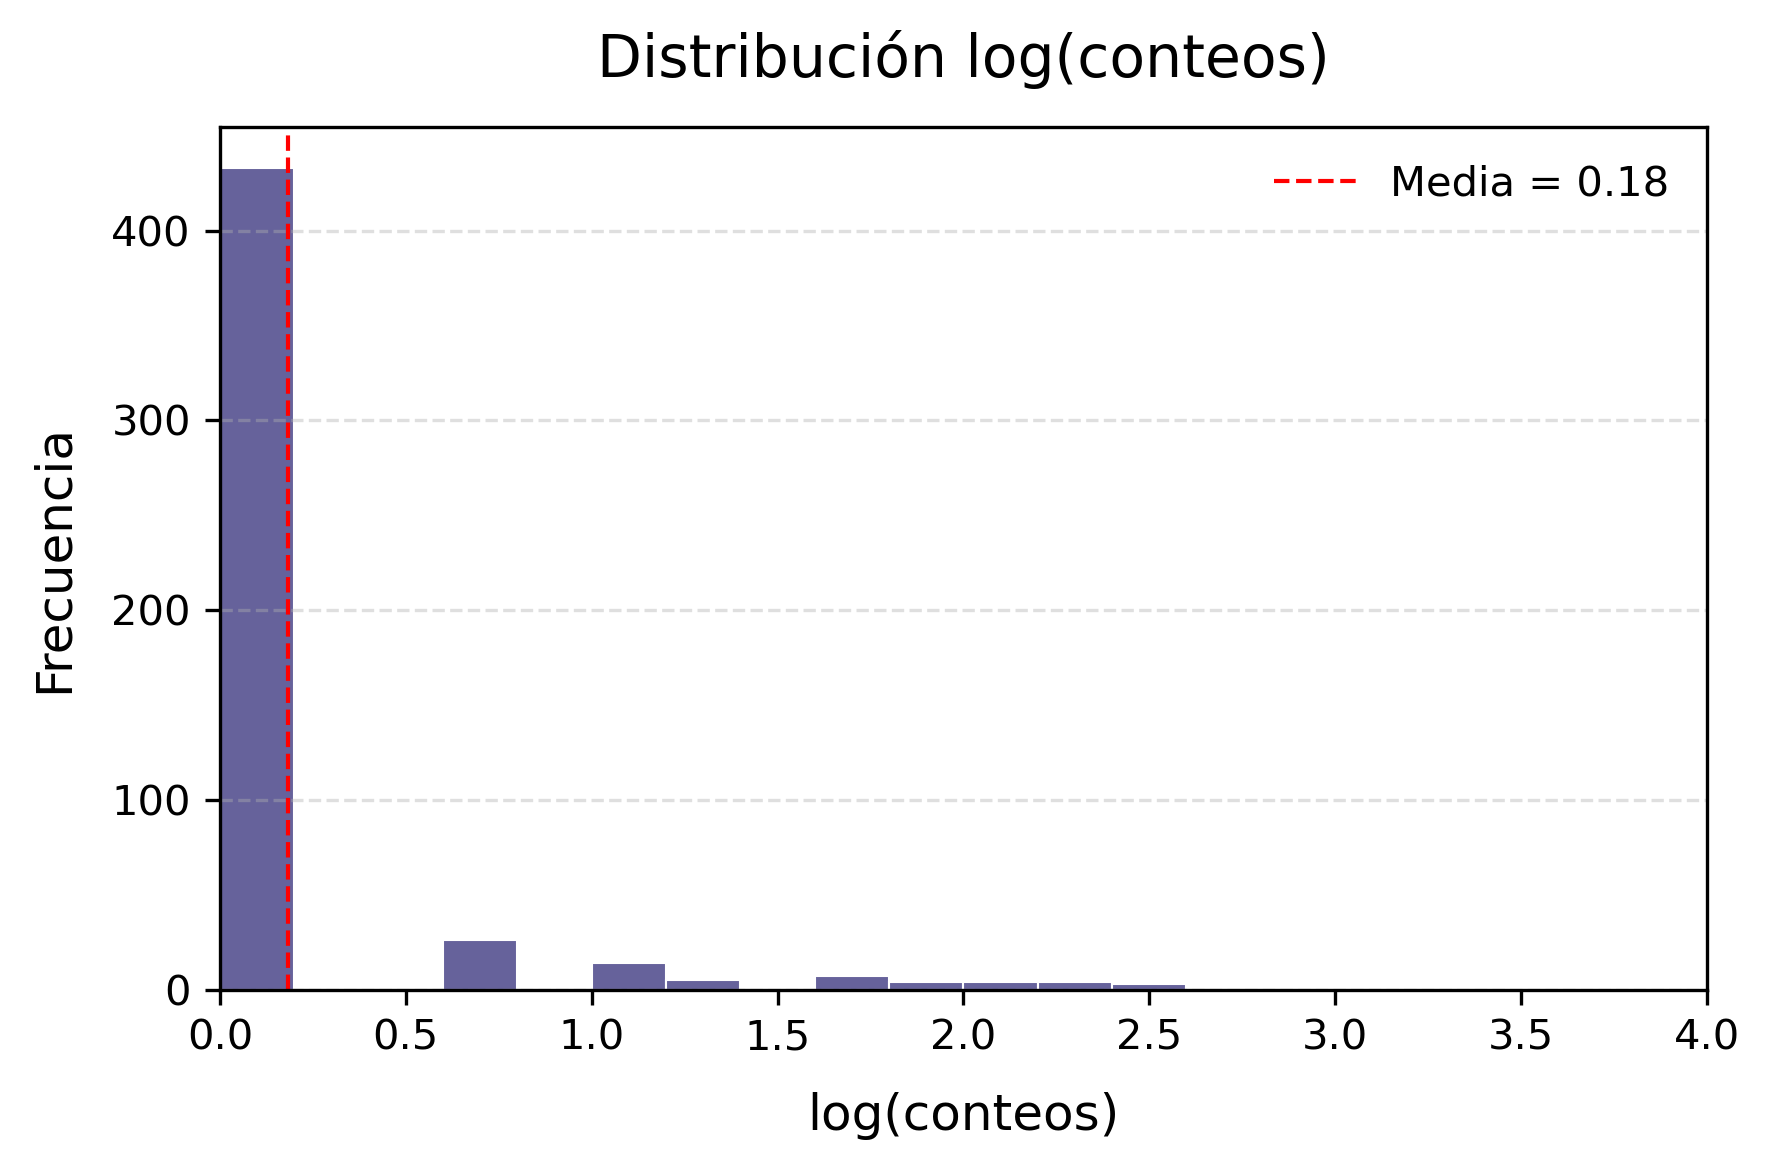

In [33]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Datos
gdf = gpd.read_file("Amenaza_Enriquecida.shp")
if "count105" not in gdf.columns:
    events = (
        gpd.read_file(r"D:/Semestre 2025-1/Analisis Geoespacial/SHP/Inventario_inundaciones_lluvias_MedellinZonaUrbana.shp")
           .to_crs(gdf.crs)
    )
    joined = gpd.sjoin_nearest(
        events[["geometry"]],
        gdf[["poly_id", "geometry"]],
        how="left",
        max_distance=105,
        distance_col="dist"
    )
    counts = joined.groupby("poly_id").size()
    gdf["count105"] = gdf["poly_id"].map(counts).fillna(0).astype(int)
counts = gdf["count105"]
log_counts = np.log1p(counts)

# Estadísticos
mean_ct = counts.mean()
med_ct  = counts.median()

# Parámetros de estilo
plt.rcParams.update({
    "figure.figsize": (6,4),
    "figure.dpi": 300,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# 1) Histograma “recortado” de 0 a 10
fig, ax = plt.subplots()
bins = np.arange(0, 11, 1)  # barras de ancho 1

sns.histplot(
    counts,
    bins=bins,
    ax=ax,
    color="#332e7a",   # tu color índigo
    edgecolor="white",
    linewidth=0.5
)

# 2) Líneas de media y mediana
ax.axvline(mean_ct, color="red", linestyle="--", linewidth=1, label=f"Media = {mean_ct:.1f}")
# ax.axvline(med_ct, color="black", linestyle=":", linewidth=1, label=f"Mediana = {med_ct:.0f}")

# 3) Etiquetas y título
ax.set_xlim(0, 10)
ax.set_xticks(bins)
ax.set_xlabel("Conteo de inundaciones por polígono", labelpad=8)
ax.set_ylabel("Frecuencia", labelpad=8)
ax.set_title("Distribución de conteos", pad=12)
ax.legend(fontsize=10, frameon=False)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()
log_ct = np.log1p(counts)

# ——— 2. Estadísticos ———
mean_log = log_ct.mean()
med_log  = np.median(log_ct)

# ——— 3. Estilos globales ———
plt.rcParams.update({
    "figure.figsize": (6,4),
    "figure.dpi": 300,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# ——— 4. Histograma log — zoom 0–4 ———
fig, ax = plt.subplots()

# elige bins uniformes en [0,4]
bins = np.linspace(0, 4, 21)

sns.histplot(
    log_ct,
    bins=bins,
    ax=ax,
    color="#332e7a",   # tu índigo
    edgecolor="white",
    linewidth=0.5
)

# ——— 5. Líneas de media y mediana ———
ax.axvline(mean_log, color="red", linestyle="--", linewidth=1,
           label=f"Media = {mean_log:.2f}")
# ax.axvline(med_log, color="black", linestyle=":", linewidth=1,
           # label=f"Mediana = {med_log:.2f}")

# ——— 6. Etiquetas y formato ———
ax.set_xlim(0, 4)
ax.set_xticks(np.arange(0, 4.5, 0.5))
ax.set_xlabel("log(conteos)", labelpad=8)
ax.set_ylabel("Frecuencia", labelpad=8)
ax.set_title("Distribución log(conteos)", pad=12)
ax.legend(fontsize=10, frameon=False)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

len(y_obs) = 502 len(y_pred) = 502


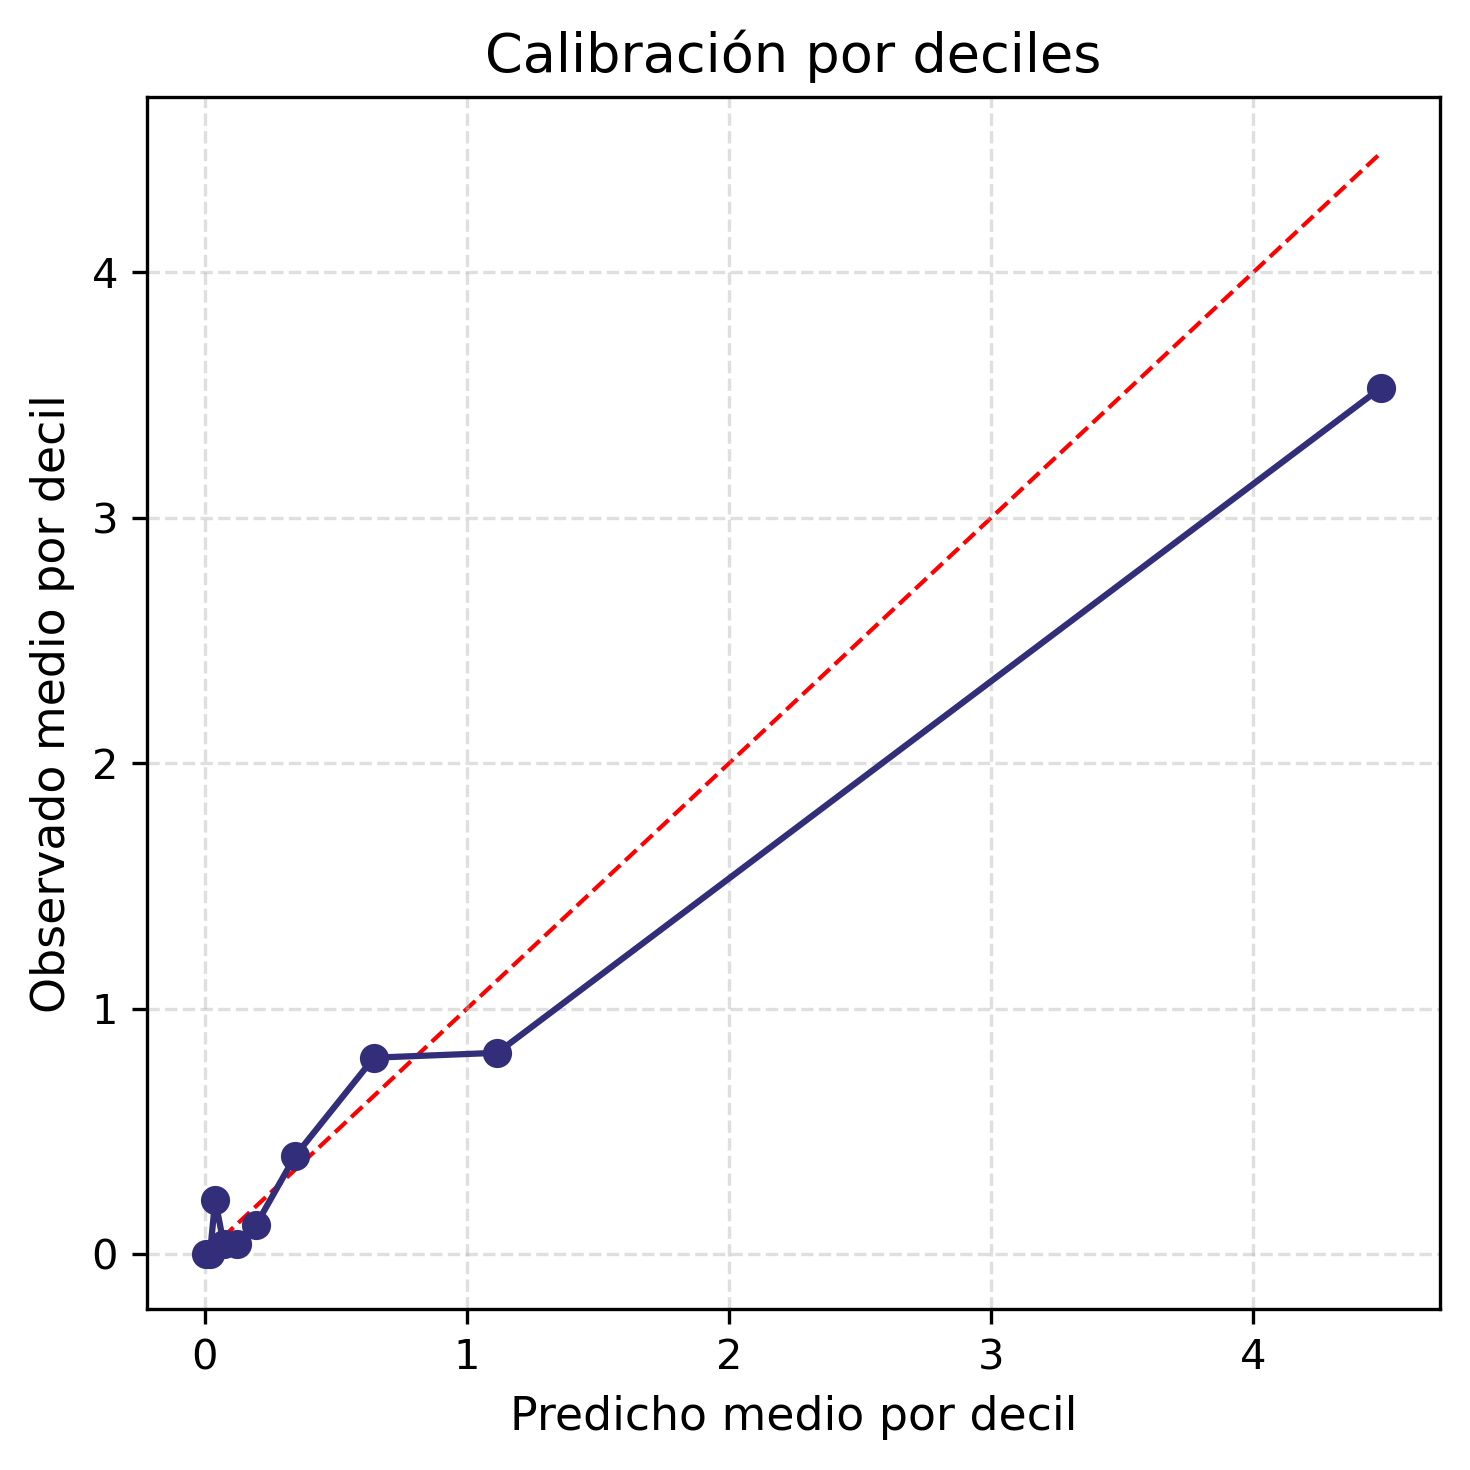

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ——— 0) Asegura que tienes en memoria:
#    gdf: tu GeoDataFrame filtrado y reproyectado
#    X, offset: tal como los usaste para ajustar model
#    model: tu GLM final con 13 EV

# 0.1) Vector observado
y_obs = gdf["count105"].values

# 0.2) Vector predicho sobre *toda* la muestra
y_pred = model.predict(X, offset=offset)

# Verificación de longitudes idénticas
print("len(y_obs) =", len(y_obs), "len(y_pred) =", len(y_pred))
# assert len(y_obs) == len(y_pred)

# ——— 1) Prepara DataFrame
df = pd.DataFrame({
    "obs":  y_obs,
    "pred": y_pred
})

# ——— 2) Crea 10 bins (deciles) por predicción
#    Si hay valores idénticos que impiden qcut, forzamos drop de duplicados
df["decile"] = pd.qcut(df["pred"], 10, labels=False, duplicates="drop")

# ——— 3) Agrega medias por decil
grp = (
    df
    .groupby("decile")
    .agg(obs_mean=("obs","mean"), pred_mean=("pred","mean"))
    .reset_index()
)

# ——— 4) Dibuja la curva de calibración
fig, ax = plt.subplots(figsize=(5,5), dpi=300)
ax.plot(
    grp["pred_mean"], 
    grp["obs_mean"], 
    marker="o", 
    linestyle="-", 
    color="#332e7a",
    zorder=2
)
# bisectriz ideal
ax.plot(
    [grp["pred_mean"].min(), grp["pred_mean"].max()],
    [grp["pred_mean"].min(), grp["pred_mean"].max()],
    "r--", linewidth=1, zorder=1
)

# ——— 5) Etiquetas y estilo
ax.set_xlabel("Predicho medio por decil", fontsize=11)
ax.set_ylabel("Observado medio por decil", fontsize=11)
ax.set_title("Calibración por deciles", fontsize=13)
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


C:\Users\Usuario\.conda\envs\Geoespacial\Lib\site-packages\statsmodels\graphics\gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


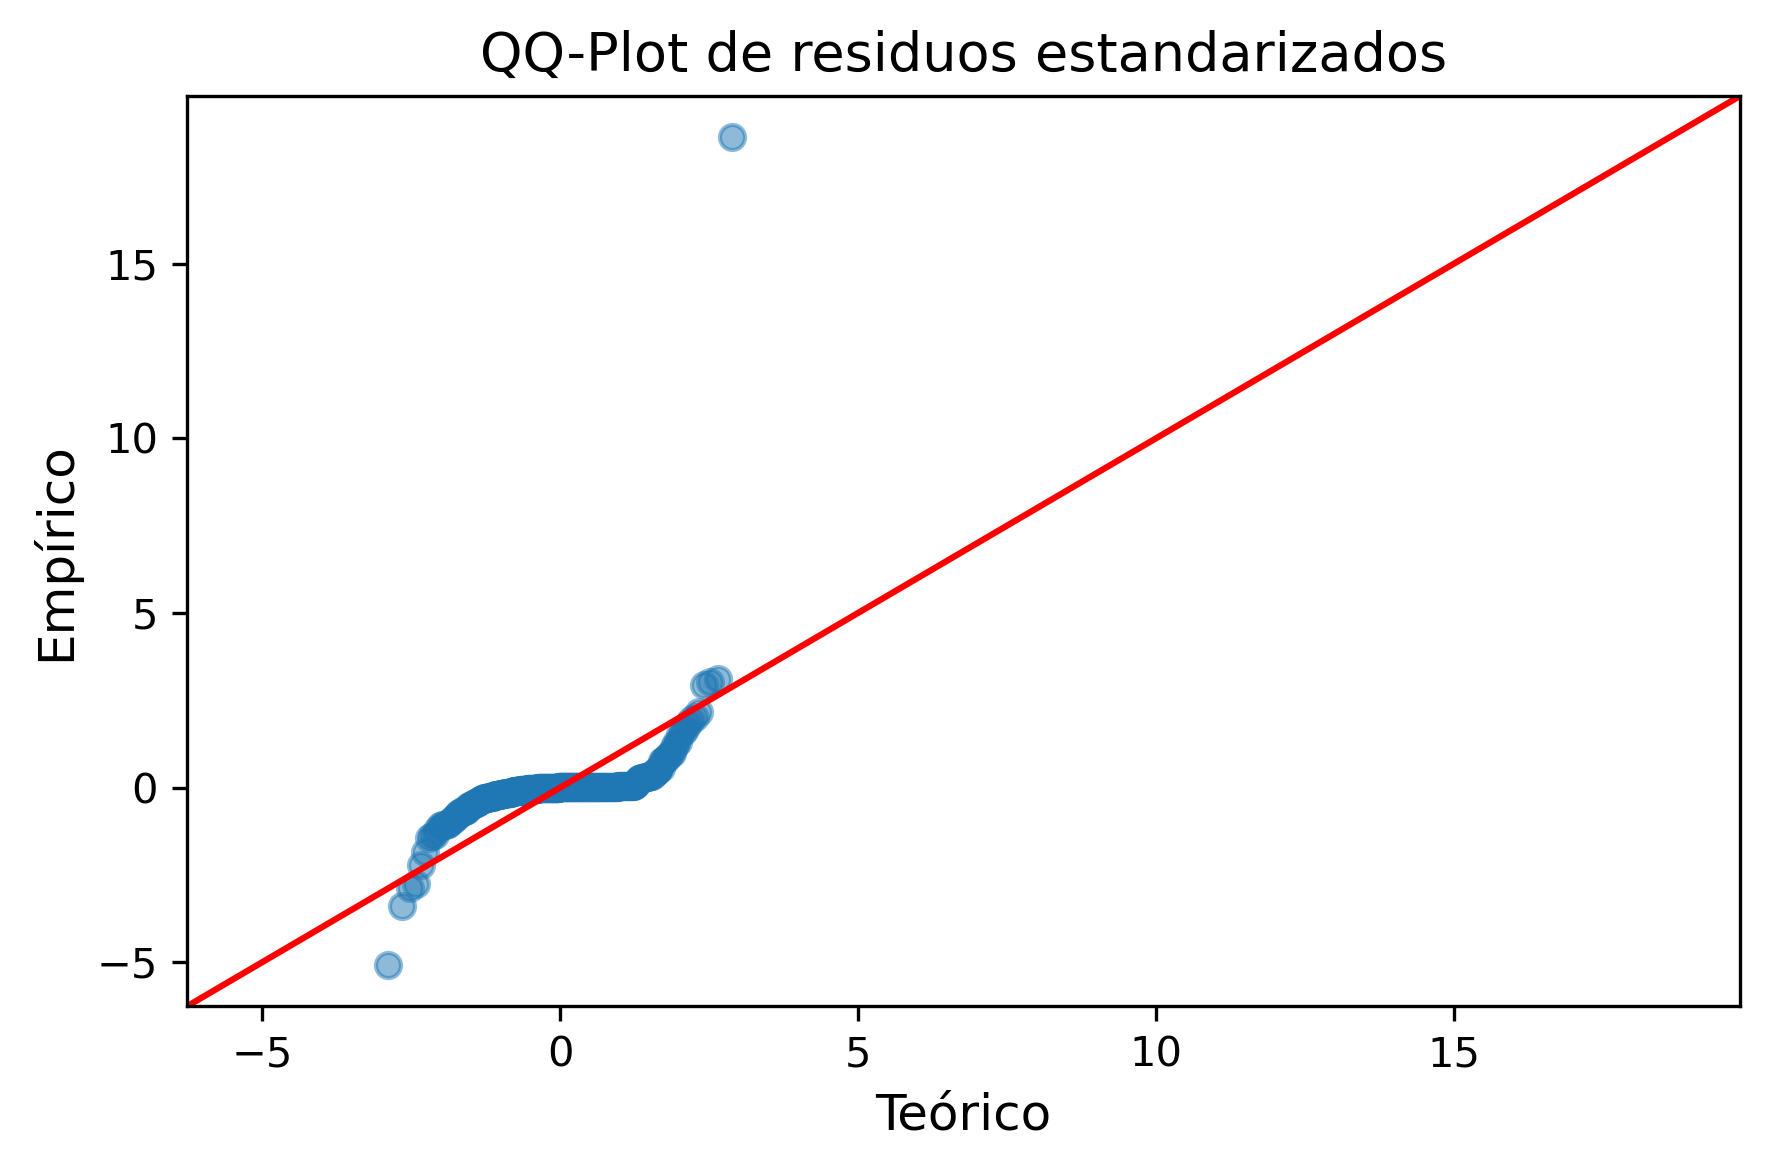

In [101]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

resid = (model.resid_response - model.resid_response.mean()) / model.resid_response.std()
sm.qqplot(resid, line="45", alpha=0.5, color="#332e7a")
plt.title("QQ-Plot de residuos estandarizados", fontsize=13)
plt.xlabel("Teórico")
plt.ylabel("Empírico")
plt.tight_layout()
plt.show()


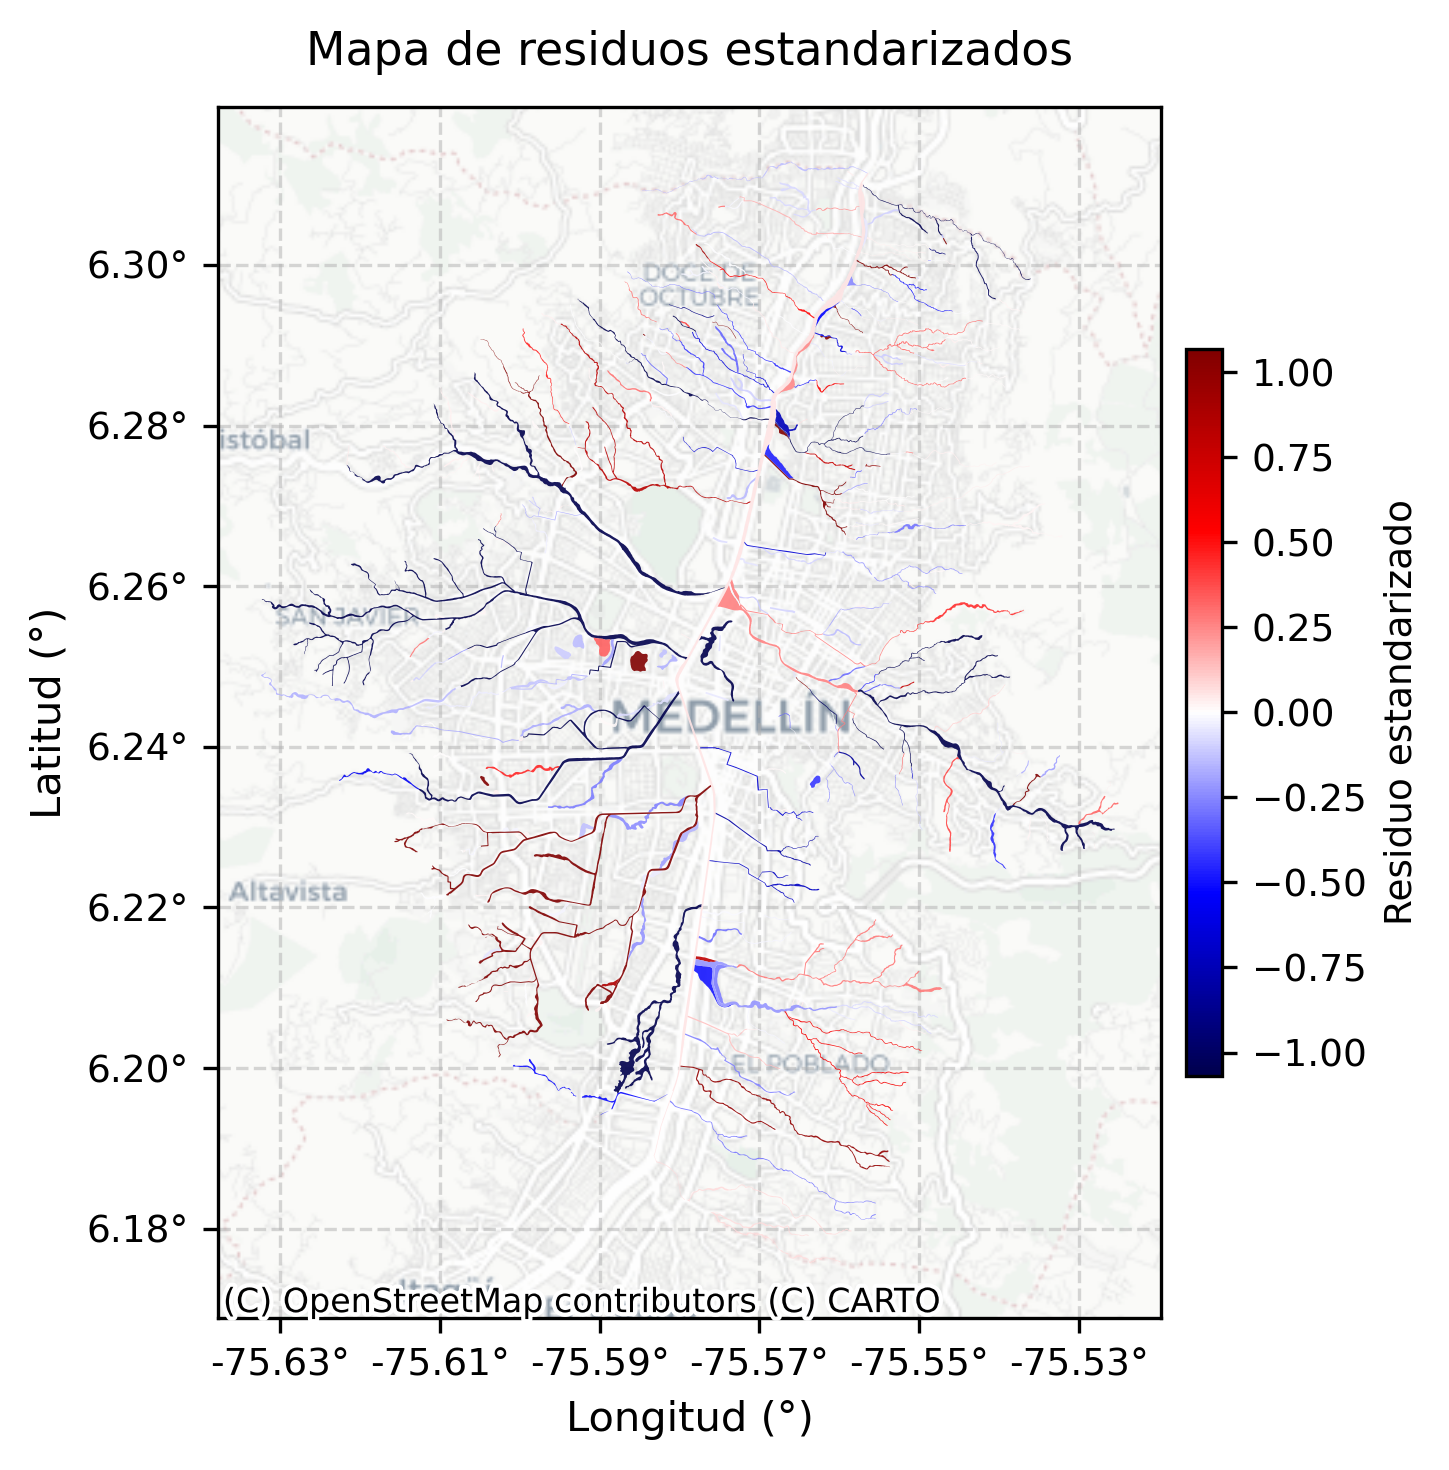

In [108]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import math
import numpy as np
from matplotlib.colors import Normalize

# ——— Función lonlat_to_merc (igual que antes) ———
R = 6378137.0
origin_shift = 2 * math.pi * R / 2.0
def lonlat_to_merc(lon, lat):
    x = lon * origin_shift / 180.0
    y = math.log(math.tan((90 + lat) * math.pi / 360.0)) * R
    return x, y

# ——— 1. Carga shapefile y reproyecta a WGS84 ———
gdf = (
    gpd.read_file("Amenaza_Enriquecida.shp")
       .to_crs(epsg=4326)
)

# ——— 2. Calcula residuos estandarizados si no existen ———
if "resid_std" not in gdf.columns:
    # asume que tienes el modelo y los residuos en memoria
    resid = model.resid_response
    gdf["resid_std"] = (resid - resid.mean()) / resid.std()

# ——— 2. Calcula bbox en grados + pequeño buffer ———
min_lon, min_lat, max_lon, max_lat = gdf.total_bounds
buffer_deg = 0.01
min_lon, min_lat = min_lon - buffer_deg, min_lat - buffer_deg
max_lon, max_lat = max_lon + buffer_deg, max_lat + buffer_deg

# Convierte bbox a WebMercator (m)
min_x, min_y = lonlat_to_merc(min_lon, min_lat)
max_x, max_y = lonlat_to_merc(max_lon, max_lat)

# ——— 3. Reproyecta a 3857 para basemap ———
gdf_m = gdf.to_crs(epsg=3857)

# ——— 4. Descarga imagen de fondo ———
zoom_level = 12
img, img_ext = ctx.bounds2img(
    min_x, min_y, max_x, max_y,
    zoom=zoom_level,
    source=ctx.providers.OpenStreetMap.Mapnik
)

# ——— 5. Dibuja todo ———
fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

# 5.1 Ejes en grados + grilla
lon_ticks = np.arange(math.floor(min_lon*100)/100, math.ceil(max_lon*100)/100, 0.02)
lat_ticks = np.arange(math.floor(min_lat*100)/100, math.ceil(max_lat*100)/100, 0.02)
x_ticks = [lonlat_to_merc(lon, 0)[0] for lon in lon_ticks]
y_ticks = [lonlat_to_merc(0, lat)[1] for lat in lat_ticks]
ax.set_xticks(x_ticks)
ax.set_xticklabels([f"{lon:.2f}°" for lon in lon_ticks], fontsize=10)
ax.set_yticks(y_ticks)
ax.set_yticklabels([f"{lat:.2f}°" for lat in lat_ticks], fontsize=10)

# 5.2 Paleta divergente centrada en 0
p95 = np.percentile(np.abs(gdf_m["resid_std"]), 95)
norm = Normalize(vmin=-p95, vmax=p95)
cmap = plt.get_cmap("seismic")

# 5.3 Polígonos “fill”
gdf_m.plot(
    column="resid_std",
    cmap=cmap,
    norm=norm,
    alpha=0.9,
    edgecolor="none",
    ax=ax,
    legend=False,
    zorder=2
)

# 5.4 Basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=12)

# 5.5 Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label("Residuo estandarizado", fontsize=9)
cbar.ax.tick_params(labelsize=9)

# 5.6 Ejes, grilla y títulos
fontsize_axes = 10
fontsize_ticks = 9
fontsize_title = 11

ax.tick_params(axis='both', labelsize=fontsize_ticks)
ax.set_xlabel("Longitud (°)", fontsize=fontsize_axes)
ax.set_ylabel("Latitud (°)", fontsize=fontsize_axes)
ax.set_title("Mapa de residuos estandarizados", fontsize=fontsize_title, pad=10)
ax.grid(True, linestyle="--", alpha=0.5, zorder=1)

plt.tight_layout()
plt.show()


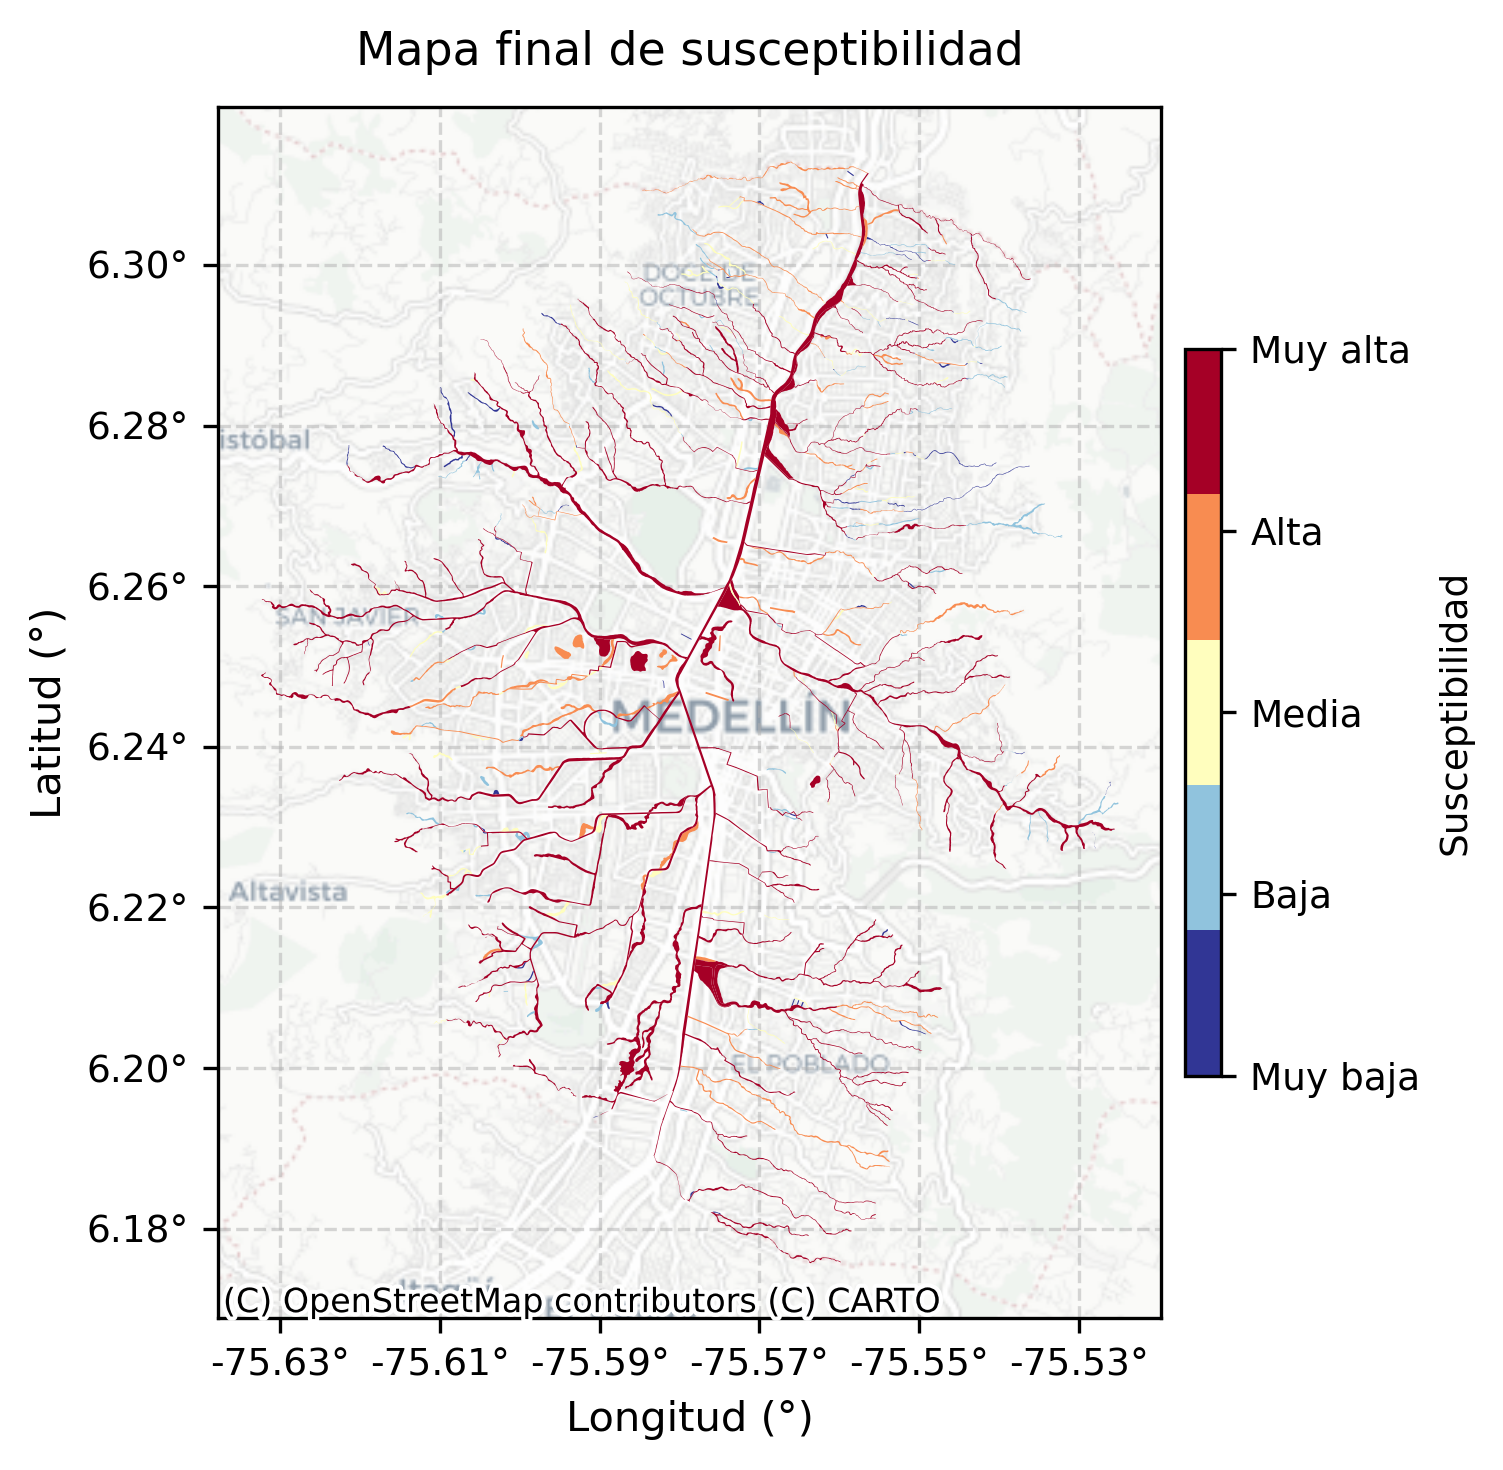

In [125]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
import math
from matplotlib.colors import ListedColormap, Normalize


# ——— 1) Calcula predicciones de conteos (no tasa) y crea índice de susceptibilidad
count_hat = model.predict(X, offset=offset)      # array de longitud n
gdf["count_hat"]    = count_hat
# cinco clases por cuantiles: 0 (muy baja) … 4 (muy alta)
gdf["suscep_idx"] = pd.qcut(
    gdf["count_hat"],
    5,
    labels=False,
    duplicates="drop"
).astype(int)

# (Opcional) etiquetas
labels = ["Muy baja","Baja","Media","Alta","Muy alta"]
gdf["suscep_cat"] = pd.Categorical.from_codes(
    gdf["suscep_idx"],
    categories=labels
)

# ——— 2) BBox en grados + buffer ———
# pasa a 4326 para calcular bounds en lon/lat
gdf4326 = gdf.to_crs(epsg=4326)
min_lon, min_lat, max_lon, max_lat = gdf4326.total_bounds
buffer_deg = 0.01
min_lon, min_lat = min_lon - buffer_deg, min_lat - buffer_deg
max_lon, max_lat = max_lon + buffer_deg, max_lat + buffer_deg

# Funciones lon/lat ⇆ WebMercator
R = 6378137.0
origin_shift = 2 * math.pi * R / 2.0
def lonlat_to_merc(lon, lat):
    x = lon * origin_shift / 180.0
    y = math.log(math.tan((90 + lat) * math.pi / 360.0)) * R
    return x, y

# convierte bbox a Mercator
min_x, min_y = lonlat_to_merc(min_lon, min_lat)
max_x, max_y = lonlat_to_merc(max_lon, max_lat)

# ——— 3) Tile de fondo ———
zoom_level = 12
img, img_ext = ctx.bounds2img(
    min_x, min_y, max_x, max_y,
    zoom=zoom_level,
    source=ctx.providers.OpenStreetMap.Mapnik
)

# 5.2 Paleta discreta de 5 clases (YlOrRd)
cmap = ListedColormap([
    "#ffffb2",  # Muy baja (amarillo pálido)
    "#fecc5c",  # Baja
    "#fd8d3c",  # Media
    "#f03b20",  # Alta
    "#bd0026",  # Muy alta (rojo intenso)
])
norm = Normalize(vmin=0, vmax=4)

import numpy as np
from matplotlib.colors import Normalize, ListedColormap
from matplotlib.patches import Patch

# ——— 5. Dibuja todo ———
fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

# 5.1 Ejes en grados + grilla
lon_ticks = np.arange(math.floor(min_lon*100)/100, math.ceil(max_lon*100)/100, 0.02)
lat_ticks = np.arange(math.floor(min_lat*100)/100, math.ceil(max_lat*100)/100, 0.02)
x_ticks = [lonlat_to_merc(lon, 0)[0] for lon in lon_ticks]
y_ticks = [lonlat_to_merc(0, lat)[1] for lat in lat_ticks]
ax.set_xticks(x_ticks)
ax.set_xticklabels([f"{lon:.2f}°" for lon in lon_ticks], fontsize=10)
ax.set_yticks(y_ticks)
ax.set_yticklabels([f"{lat:.2f}°" for lat in lat_ticks], fontsize=10)

# 5.2 Paleta discreta de 5 clases (amarillos más vivos → rojos)
cmap_cont = plt.get_cmap("RdYlBu_r")
cmap = ListedColormap(cmap_cont(np.linspace(0,1,5)))
norm = Normalize(vmin=0, vmax=4)

# 5.3 Polígonos “fill”
gdf_m.plot(
    column="suscep_idx",
    cmap=cmap,
    norm=norm,
    edgecolor="none",
    ax=ax,
    legend=False,
    zorder=2
)

# 5.4 Basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=12)

# 5.5 Colorbar discreto
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, ticks=[0,1,2,3,4], shrink=0.6, pad=0.02)
cbar.set_ticklabels(["Muy baja","Baja","Media","Alta","Muy alta"])
cbar.set_label("Susceptibilidad", fontsize=9)
cbar.ax.tick_params(labelsize=9)

# 5.6 Ejes, grilla y títulos
fontsize_axes = 10
fontsize_ticks = 9
fontsize_title = 11

ax.tick_params(axis='both', labelsize=fontsize_ticks)
ax.set_xlabel("Longitud (°)", fontsize=fontsize_axes)
ax.set_ylabel("Latitud (°)", fontsize=fontsize_axes)
ax.set_title("Mapa final de susceptibilidad", fontsize=fontsize_title, pad=10)
ax.grid(True, linestyle="--", alpha=0.5, zorder=1)

plt.tight_layout()
plt.show()


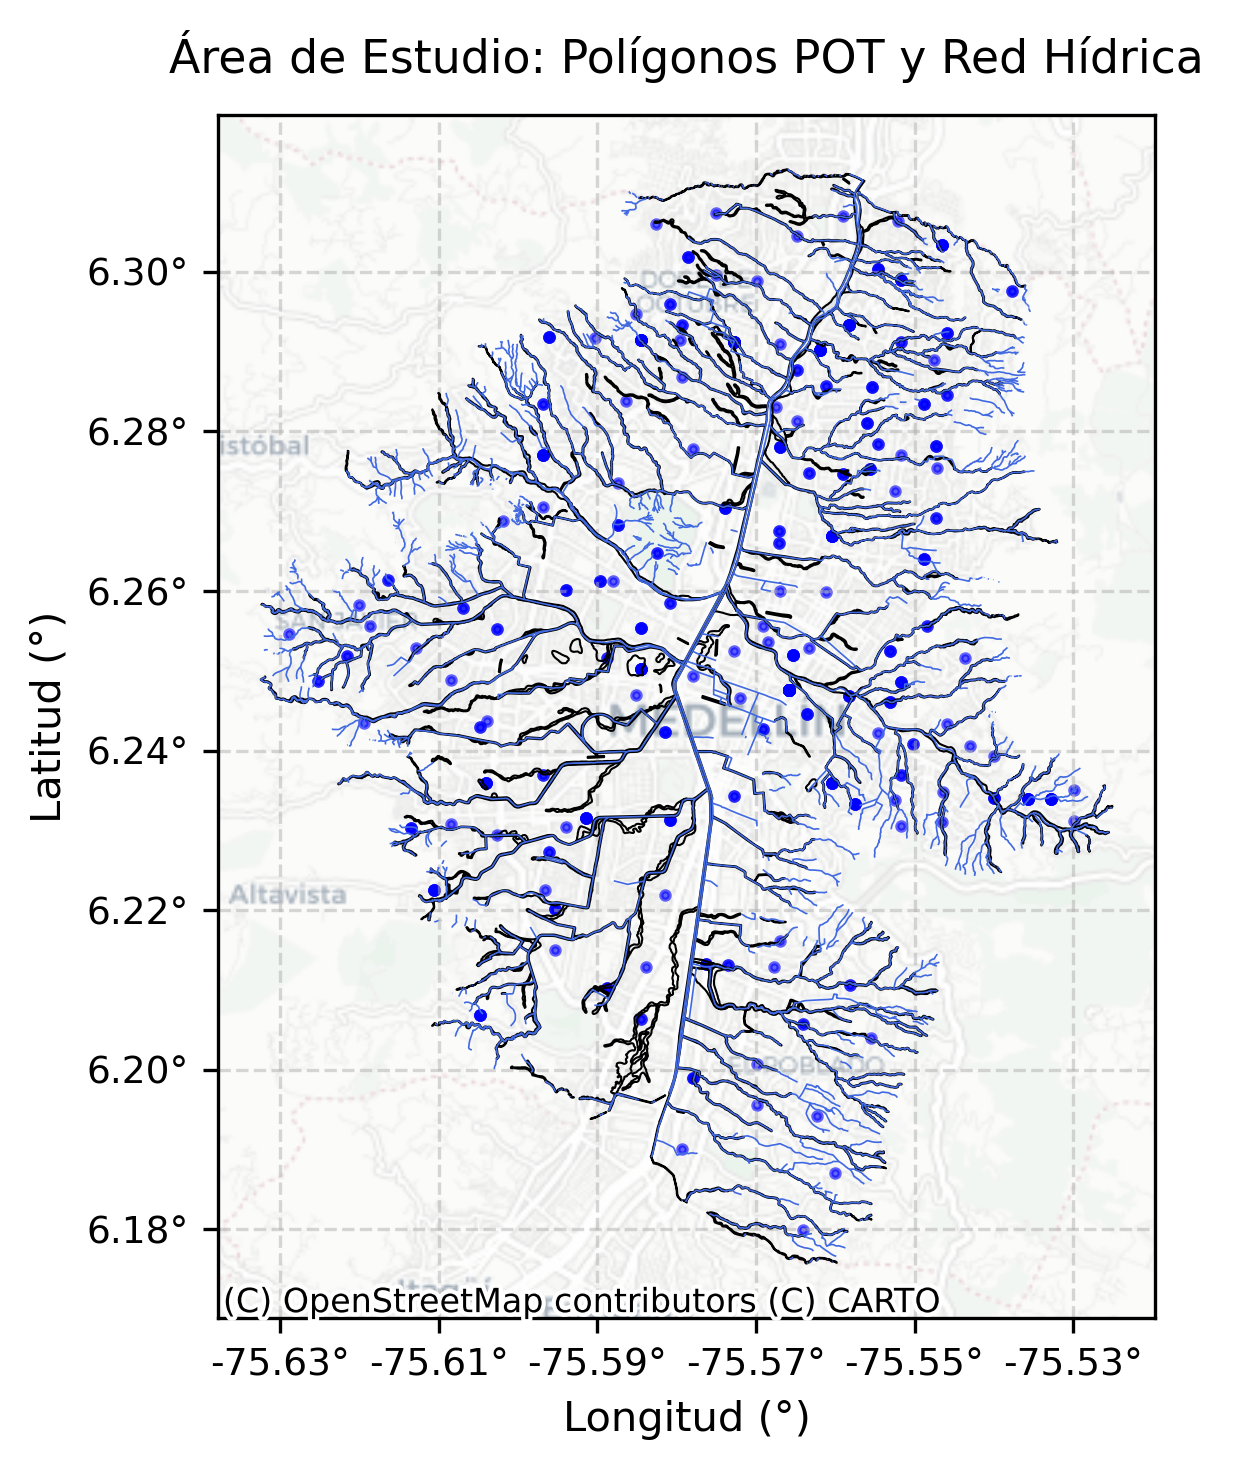

In [47]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
import math
from matplotlib.colors import ListedColormap, Normalize

# ——— 1. Carga shapefiles en WGS84 ———
gdf = gpd.read_file("Amenaza_Enriquecida.shp").to_crs(epsg=4326)
streams = gpd.read_file(r"D:\Semestre 2025-1\Analisis Geoespacial\SHP\Red_hidrica_Medellin_ZonaUrbana.shp").to_crs(epsg=4326)
puntos=gpd.read_file(r"D:/Semestre 2025-1/Analisis Geoespacial/SHP/Inventario_inundaciones_lluvias_MedellinZonaUrbana.shp").to_crs(epsg=4326)
# ——— 2) BBox en grados + buffer ———
# pasa a 4326 para calcular bounds en lon/lat
gdf_m = gdf.to_crs(epsg=3857)
streams_m = streams.to_crs(epsg=3857)
puntos_m=puntos.to_crs(epsg=3857)
min_lon, min_lat, max_lon, max_lat = gdf4326.total_bounds
buffer_deg = 0.01
min_lon, min_lat = min_lon - buffer_deg, min_lat - buffer_deg
max_lon, max_lat = max_lon + buffer_deg, max_lat + buffer_deg

# Funciones lon/lat ⇆ WebMercator
R = 6378137.0
origin_shift = 2 * math.pi * R / 2.0
def lonlat_to_merc(lon, lat):
    x = lon * origin_shift / 180.0
    y = math.log(math.tan((90 + lat) * math.pi / 360.0)) * R
    return x, y

# convierte bbox a Mercator
min_x, min_y = lonlat_to_merc(min_lon, min_lat)
max_x, max_y = lonlat_to_merc(max_lon, max_lat)

# ——— 3) Tile de fondo ———
zoom_level = 12
img, img_ext = ctx.bounds2img(
    min_x, min_y, max_x, max_y,
    zoom=zoom_level,
    source=ctx.providers.OpenStreetMap.Mapnik
)



import numpy as np
from matplotlib.colors import Normalize, ListedColormap
from matplotlib.patches import Patch

# ——— 5. Dibuja todo ———
fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

# 5.1 Ejes en grados + grilla
lon_ticks = np.arange(math.floor(min_lon*100)/100, math.ceil(max_lon*100)/100, 0.02)
lat_ticks = np.arange(math.floor(min_lat*100)/100, math.ceil(max_lat*100)/100, 0.02)
x_ticks = [lonlat_to_merc(lon, 0)[0] for lon in lon_ticks]
y_ticks = [lonlat_to_merc(0, lat)[1] for lat in lat_ticks]
ax.set_xticks(x_ticks)
ax.set_xticklabels([f"{lon:.2f}°" for lon in lon_ticks], fontsize=10)
ax.set_yticks(y_ticks)
ax.set_yticklabels([f"{lat:.2f}°" for lat in lat_ticks], fontsize=10)



# Polígonos POT: borde negro, sin relleno
puntos_m.plot(
    ax=ax,
    color='blue',
    markersize=4,
    alpha=0.6
)

gdf_m.plot(
    facecolor="none",
    edgecolor="black",
    linewidth=0.5,
    ax=ax,
    zorder=2
)

# Red hídrica: azul
streams_m.plot(
    ax=ax,
    color="royalblue",
    linewidth=0.4,
    zorder=3
)

# 5.4 Basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=12, alpha=0.8)



# 5.6 Ejes, grilla y títulos
fontsize_axes = 10
fontsize_ticks = 9
fontsize_title = 11

ax.tick_params(axis='both', labelsize=fontsize_ticks)
ax.set_xlabel("Longitud (°)", fontsize=fontsize_axes)
ax.set_ylabel("Latitud (°)", fontsize=fontsize_axes)
ax.set_title("Área de Estudio: Polígonos POT y Red Hídrica", fontsize=fontsize_title, pad=10)
ax.grid(True, linestyle="--", alpha=0.5, zorder=1)

plt.tight_layout()
plt.show()
